# Crystallizer: a crystal structure from the diffusion density

This notebook shows how to use the [`Crystallizer`][gemdat.crystallizer.Crystallizer] to
reconstruct a symmetry-fitted crystal structure (and a CIF file) from the occupancy density
of a molecular dynamics trajectory.

The pipeline is:

1. Load a trajectory and keep the diffusing species.
2. (Optionally) **fold** a supercell trajectory back onto the conventional cell.
3. Turn its positions into an occupancy **density** volume.
4. Segment the density into candidate **sites** with partial occupancies.
5. Combine the sites with the time-averaged host framework and fit the highest space group.

Here we use a long (75&nbsp;000 frame) Li₆PS₅Br argyrodite run, simulated in a
2&times;1&times;1 supercell.

In [1]:
from gemdat import Trajectory

# Point this at your own vasprun.xml. `from_vasprun` caches the parse next to the
# file, so re-loading is fast. The bundled example is available as
# `from gemdat.utils import VASPRUN` (but it is much shorter).
VASPRUN = '/home/vikko/Downloads/vasprun.xml'

trajectory = Trajectory.from_vasprun(VASPRUN)
trajectory

Full Formula (Li48 P8 S40 Br8)
Reduced Formula: Li6PS5Br
abc   :  19.873726   9.919447   9.916454
angles:  90.214114  90.859135  89.950474
pbc   :       True       True       True
Constant lattice (True)
Sites (104)
Time steps (75000)

Keep only the diffusing species, lithium.

In [2]:
diff_trajectory = trajectory.filter('Li')
diff_trajectory

Full Formula (Li48)
Reduced Formula: Li
abc   :  19.873726   9.919447   9.916454
angles:  90.214114  90.859135  89.950474
pbc   :       True       True       True
Constant lattice (True)
Sites (48)
Time steps (75000)

## Folding the supercell

The simulation cell is a 2&times;1&times;1 supercell, so it contains two copies of the
conventional cell stacked along **a**. Because every copy samples the *same*
crystallographic sites, we can **fold** the two copies onto each other to reinforce the
density on the conventional cell.

We fold the **trajectory** rather than the density grid: folding the grid would require
splitting the voxels evenly along each supercell axis, which is not guaranteed (the grid
may have an odd number of voxels). Folding the fractional coordinates instead — multiply
each coordinate by the supercell factor along its axis and wrap back into the cell — and
re-binning gives a clean voxel grid on the conventional cell every time.

Folding stacks `n_copies = prod(supercell)` periodic images on top of each other. Left as
is, that puts `n_copies` times too many atoms in the (now smaller) cell, so the site
occupancies — the mean number of atoms per site *per frame* — come out inflated past 1 and
the [`Crystallizer`][gemdat.crystallizer.Crystallizer] raises *"Species occupancies sum to
more than 1"*. To keep the occupancies normalized we redistribute the overlaid images along
the **time** axis: the density is identical, but the folded trajectory has `n_copies` times
more frames, each holding one image's worth of atoms.

In [3]:
import numpy as np

from gemdat import Trajectory


def fold_trajectory(trajectory: Trajectory, supercell: tuple[int, int, int]) -> Trajectory:
    """Fold a supercell trajectory back onto the conventional cell.

    Each fractional coordinate is multiplied by the supercell factor along its
    axis and wrapped into [0, 1), and the lattice is shrunk to match.

    Folding overlays ``n_copies = prod(supercell)`` periodic images. To keep the
    site occupancies normalized (otherwise they scale with ``n_copies`` and
    exceed 1), the overlaid images are spread over the time axis: the density is
    unchanged, but the trajectory gains ``n_copies`` times more frames, each
    holding one image's worth of atoms. Expects a single-species (e.g. already
    filtered) trajectory.
    """
    sc = np.array(supercell)
    n_copies = int(np.prod(sc))

    coords = (trajectory.positions * sc) % 1
    n_frames, n_atoms, _ = coords.shape
    if n_atoms % n_copies:
        raise ValueError(f'{n_atoms} atoms are not divisible over {n_copies} supercell images.')

    # Reinterpret the n_copies overlaid images as extra frames so the cell holds
    # the right number of atoms per frame and occupancies stay normalized.
    coords = coords.reshape(n_frames * n_copies, n_atoms // n_copies, 3)
    species = trajectory.species[: n_atoms // n_copies]
    matrix = trajectory.get_lattice().matrix / sc[:, None]

    return Trajectory(
        species=species,
        coords=coords,
        lattice=matrix,
        time_step=trajectory.time_step,
        metadata=trajectory.metadata,
    )


folded_trajectory = fold_trajectory(diff_trajectory, supercell=(2, 1, 1))
folded_trajectory

Full Formula (Li24)
Reduced Formula: Li
abc   :   9.936863   9.919447   9.916454
angles:  90.214114  90.859135  89.950474
pbc   :       True       True       True
Constant lattice (True)
Sites (24)
Time steps (150000)

## The occupancy density

The diffusing lithium visits its (meta-)stable sites over and over, so its time-averaged
density already traces out the lithium sublattice. We bin the positions onto a voxel grid
with [`Trajectory.to_volume`][gemdat.Trajectory.to_volume], for both the original and the
folded trajectory.

In [4]:
resolution = 0.3  # Å

vol = diff_trajectory.to_volume(resolution=resolution)
folded_vol = folded_trajectory.to_volume(resolution=resolution)
folded_vol

Data: (33, 33, 33)
Lattice, abc:   9.936863   9.919447   9.916454
      angles:  90.214114  90.859135  89.950474
         pbc:       True       True       True
Label: trajectory

The density before and after folding, projected onto the **a**-**b** plane (summed
over **c**). The supercell (left) is twice as long along **a**; after folding (right) the
two halves overlap onto a single, more sharply defined set of sites on the conventional
cell.

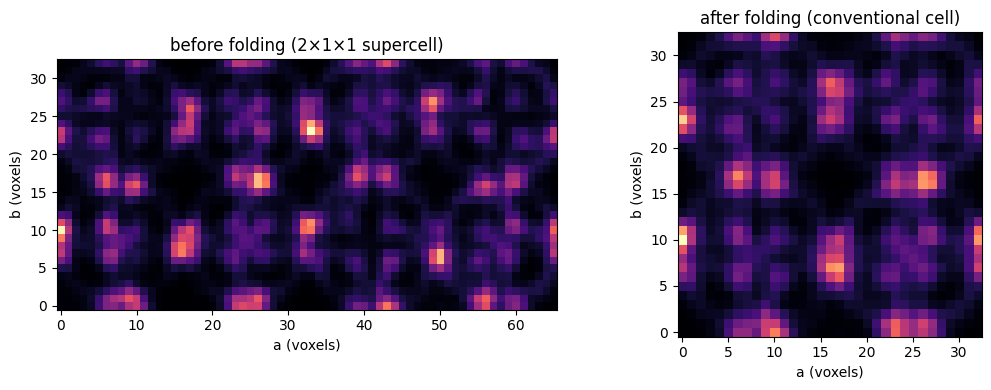

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, v, title in (
    (axes[0], vol, 'before folding (2×1×1 supercell)'),
    (axes[1], folded_vol, 'after folding (conventional cell)'),
):
    ax.imshow(v.data.sum(axis=2).T, origin='lower', aspect='equal', cmap='magma')
    ax.set_title(title)
    ax.set_xlabel('a (voxels)')
    ax.set_ylabel('b (voxels)')

fig.tight_layout()

## Finding the sites

We run the [`Crystallizer`][gemdat.crystallizer.Crystallizer] on the **folded** trajectory.
[`Crystallizer.mobile_sites`][gemdat.crystallizer.Crystallizer.mobile_sites] segments the
density into discrete sites with partial occupancies using a watershed algorithm.

How many sites are found is controlled by a few knobs (passed through to
[`Volume.find_peaks`][gemdat.Volume.find_peaks] / the watershed):

- **`background_level`** — fraction of the peak density used as the segmentation floor. This
  is the main knob: raising it trims weak, spurious basins (and shrinks the basins, keeping
  occupancies well below 1).
- **`resolution`** — the voxel size set above. Too fine over-segments each site into several
  basins; too coarse merges neighbouring sites.
- **`threshold`** — the difference-of-Gaussian peak-detection threshold (passed to
  `find_peaks`); raise it to drop faint peaks.

Argyrodite has 48 lithium (48*h*) sites in the conventional cell. With `background_level=0.2`
the segmentation lands exactly on those 48 sites.

In [6]:
from gemdat.crystallizer import Crystallizer

background_level = 0.2

cr = Crystallizer.from_trajectory(
    folded_trajectory, floating_specie='Li', resolution=resolution
)

sites = cr.mobile_sites(background_level=background_level)

# `mobile_sites` labels each site by species *and* occupancy (e.g. 'Li:0.275'),
# which makes every site a distinct label. Relabel to the plain element so the
# occupancy doesn't leak into the site labels (and the plot colours by element).
for site in sites:
    site.label = 'Li'

print(f'found {len(sites)} lithium sites')
print(f'max occupancy: {max(s.species.num_atoms for s in sites):.2f}')
sites[:5]

found 48 lithium sites
max occupancy: 0.93


[PeriodicSite: Li (Li:0.275) (1.851, 8.157, 9.64) [0.1932, 0.8239, 0.9754],
 PeriodicSite: Li (Li:0.141) (3.042, 7.2, 9.627) [0.3131, 0.7273, 0.9747],
 PeriodicSite: Li (Li:0.226) (4.761, 7.028, 7.925) [0.4848, 0.7096, 0.8043],
 PeriodicSite: Li (Li:0.234) (4.771, 8.232, 6.745) [0.4848, 0.8308, 0.6856],
 PeriodicSite: Li (Li:0.308) (0.183, 6.983, 6.794) [0.02323, 0.7051, 0.6869]]

Overlaying the sites (red) on the folded density isosurface.

In [7]:
fig = folded_vol.plot_3d(structure=sites)

# Render to a static image to keep the notebook small; use `fig.show()` for the
# interactive version.
from IPython.display import Image

Image(fig.to_image(format='png', width=700, height=600))
fig.show()

## Comparison with the expected sites

The bundled reference structure `src/gemdat/data/argyrodite.cif` (loaded with
`load_known_material('argyrodite')`) lists the 48 ideal lithium (48*h*) sites. Overlaying
them on the folded density shows how well the simulated density reproduces the known
lithium sublattice.

In [8]:
from pymatgen.core import Structure

from gemdat.io import load_known_material

# The bundled argyrodite reference (F-43m) only lists the 48 Li (48h) sites.
# Place them in the folded volume's lattice so they share its coordinate frame.
reference = load_known_material('argyrodite')
expected_sites = Structure(
    lattice=folded_vol.lattice,
    species=[site.specie for site in reference],
    coords=[site.frac_coords for site in reference],
)

fig = folded_vol.plot_3d(structure=expected_sites)
Image(fig.to_image(format='png', width=700, height=600))
fig.show()

## A richer reference: three Li Wyckoff sites

The `argyrodite.cif` above only lists the single 48*h* lithium position. A more complete
description of the lithium sublattice spreads the lithium over **three** Wyckoff sites
(48*h*, a second 48*h*, and 16*e*). The bundled `src/gemdat/data/argyrodite_48h48h16e.cif`
captures this; overlaying its 112 lithium sites on the folded density shows how the
secondary positions line up with the simulated density.

In [9]:
# `Structure`, `load_known_material` and `Image` are already imported above.
reference_3site = load_known_material('argyrodite_48h48h16e')
expected_sites_3site = Structure(
    lattice=folded_vol.lattice,
    species=[site.specie for site in reference_3site],
    coords=[site.frac_coords for site in reference_3site],
    # Keep the Wyckoff labels ('48h', '48h2', '16e') so plot_3d colours the
    # three site types distinctly.
    labels=reference_3site.labels,
)

fig = folded_vol.plot_3d(structure=expected_sites_3site)
Image(fig.to_image(format='png', width=700, height=600))
fig.show()

### Segmenting the density into ~112 sites

The earlier `background_level=0.2` run lands on the 48 dominant 48*h* sites. To resolve the
finer structure of the three-Wyckoff reference (112 lithium sites), we segment the density
more aggressively: a finer voxel grid (smaller `resolution`) splits each broad basin into
its sub-peaks, and a low `background_level` keeps the weaker secondary sites. With
`resolution=0.13` Å and `background_level=0.05` the watershed finds ~112 sites, matching the
`argyrodite_48h48h16e.cif` count.

In [10]:
fine_resolution = 0.13  # Å
fine_background_level = 0.05

cr_fine = Crystallizer.from_trajectory(
    folded_trajectory, floating_specie='Li', resolution=fine_resolution
)
sites_fine = cr_fine.mobile_sites(background_level=fine_background_level)
for site in sites_fine:
    site.label = 'Li'

print(f'found {len(sites_fine)} lithium sites (reference has 112)')
print(f'max occupancy: {max(s.species.num_atoms for s in sites_fine):.2f}')

fig = folded_vol.plot_3d(structure=sites_fine)
Image(fig.to_image(format='png', width=700, height=600))
fig.show()

found 112 lithium sites (reference has 112)
max occupancy: 0.53


## Crystallize

Finally, [`Crystallizer.crystallize`][gemdat.crystallizer.Crystallizer.crystallize] combines
the mobile sites with the time-averaged framework and fits the highest space group that is
consistent with the structure, scanning a range of symmetry tolerances. The same
`background_level` is forwarded to the site segmentation.

In [11]:
result = cr.crystallize(background_level=background_level)

print(f'space group: {result.spacegroup_symbol} (#{result.spacegroup_number})')
print(f'symprec:     {result.symprec} Å')
print(f'sites:       {len(result.structure)}')
result.structure

space group: P1 (#1)
symprec:     0.01 Å
sites:       48


Structure Summary
Lattice
    abc : 9.936863093334848 9.919447462770213 9.916453611751622
 angles : 90.2141142206055 90.85913455159614 89.95047426162805
 volume : 977.3298704775843
      A : np.float64(9.936589555) np.float64(0.00310405) np.float64(-0.07366489)
      B : np.float64(0.0053182) np.float64(9.91942326) np.float64(-0.02125729)
      C : np.float64(-0.0751747) np.float64(-0.01576718) np.float64(9.91615613)
    pbc : True True True
PeriodicSite: Li:0.275 (1.851, 8.157, 9.64) [0.1932, 0.8239, 0.9754]
PeriodicSite: Li:0.141 (3.042, 7.2, 9.627) [0.3131, 0.7273, 0.9747]
PeriodicSite: Li:0.226 (4.761, 7.028, 7.925) [0.4848, 0.7096, 0.8043]
PeriodicSite: Li:0.234 (4.771, 8.232, 6.745) [0.4848, 0.8308, 0.6856]
PeriodicSite: Li:0.308 (0.183, 6.983, 6.794) [0.02323, 0.7051, 0.6869]
PeriodicSite: Li:0.0573 (0.2449, 8.291, 7.981) [0.0303, 0.8371, 0.8068]
PeriodicSite: Li:0.151 (1.855, 9.884, 7.896) [0.1922, 0.9976, 0.7998]
PeriodicSite: Li:0.299 (3.107, 9.807, 6.566) [0.3172, 0.9896, 0.

The result can be written straight to a CIF file with the fitted symmetry:

```python
cr.to_cif('argyrodite_crystallized.cif', background_level=background_level)
```

> **Note.** For this thermally noisy, site-disordered Li₆PS₅Br run the fit comes out as
> low symmetry (typically P1): the S/Br framework is disordered in the MD cell, and the
> density-derived site centroids scatter by a few tenths of an &Aring;ngstr&ouml;m around the
> ideal Wyckoff positions, which is enough to break the *F*-43*m* symmetry of the ideal
> crystal. The Crystallizer reports the symmetry it can actually justify from the data
> rather than assuming the textbook answer.